In [1]:
import pandas as pd, numpy as np, os, warnings
import matplotlib.pyplot as plt, seaborn as sns
from mplsoccer import Pitch
warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)
shots   = pd.read_csv('data/shots_processed.csv')
matches = pd.read_csv('data/matches_clean.csv')
players = pd.read_csv('data/players.csv')
p_rename = {'xG': 'expected_goals', 'xA': 'expected_assists', 'web_name': 'player_name', 'now_cost': 'price'}
players.rename(columns={k:v for k,v in p_rename.items() if k in players.columns}, inplace=True)
if 'price' not in players.columns and 'now_cost' in players.columns: players.rename(columns={'now_cost': 'price'}, inplace=True)


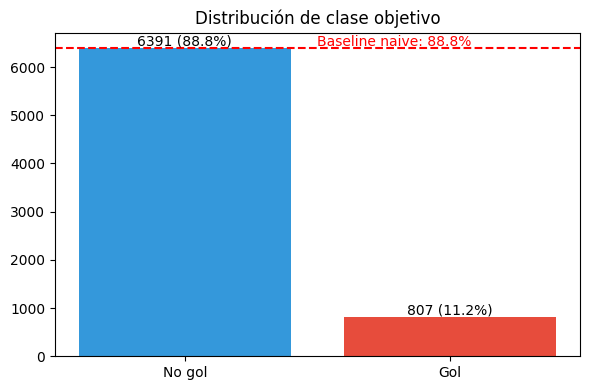

In [2]:
fig, ax = plt.subplots(figsize=(6,4))
counts = shots['is_goal'].value_counts()
ax.bar(['No gol', 'Gol'], counts.values, color=['#3498db', '#e74c3c'])
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, f"{v} ({(v/len(shots))*100:.1f}%)", ha='center')
ax.axhline(len(shots)*0.888, color='red', linestyle='--')
ax.text(0.5, len(shots)*0.888 + 50, 'Baseline naive: 88.8%', color='red')
ax.set_title('Distribución de clase objetivo')
plt.tight_layout(); plt.savefig('figures/class_distribution.png', dpi=150, bbox_inches='tight'); plt.show()

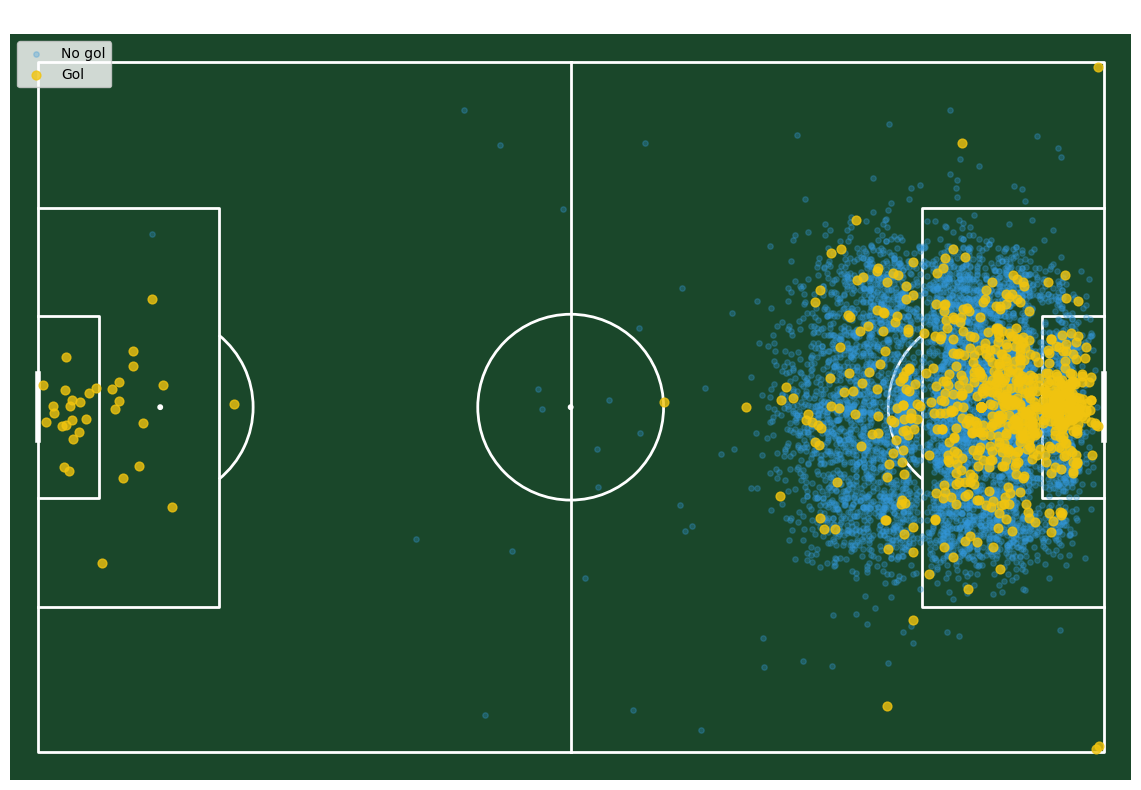

In [3]:
pitch = Pitch(pitch_type='opta', pitch_color='#1a472a', line_color='white')
fig, ax = pitch.draw(figsize=(12,8))
no_goals = shots[shots['is_goal']==0]
goals = shots[shots['is_goal']==1]
pitch.scatter(no_goals['x'], no_goals['y'], alpha=0.3, s=15, color='#3498db', ax=ax, label='No gol')
pitch.scatter(goals['x'], goals['y'], alpha=0.8, s=40, color='#f1c40f', ax=ax, label='Gol', zorder=5)
ax.set_title("Shot map — Premier League 2025/26 (GW1-GW30)", fontsize=15, color='white')
ax.legend(loc='upper left')
plt.tight_layout(); plt.savefig('figures/shot_map_all.png', dpi=150, bbox_inches='tight'); plt.show()

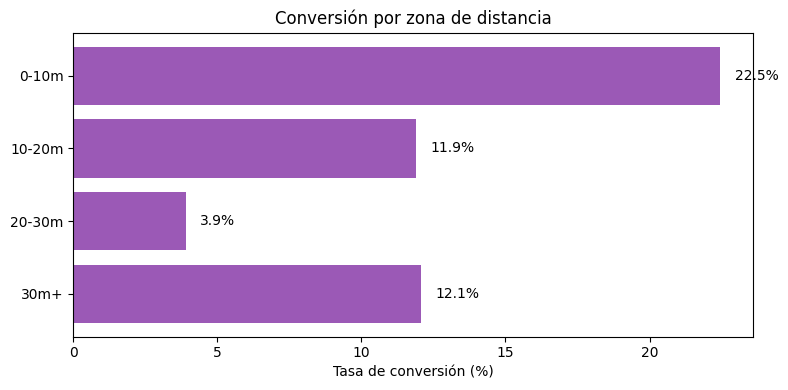

In [4]:
bins = [0, 10, 20, 30, 100]
labels = ['0-10m','10-20m','20-30m','30m+']
shots['dist_bin'] = pd.cut(shots['distance_to_goal'], bins=bins, labels=labels)
conv = shots.groupby('dist_bin')['is_goal'].mean() * 100
fig, ax = plt.subplots(figsize=(8,4))
bars = ax.barh(conv.index[::-1], conv.values[::-1], color='#9b59b6')
for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.1f}%", va='center')
ax.set_title('Conversión por zona de distancia')
ax.set_xlabel('Tasa de conversión (%)')
plt.tight_layout(); plt.savefig('figures/conversion_by_distance.png', dpi=150, bbox_inches='tight'); plt.show()

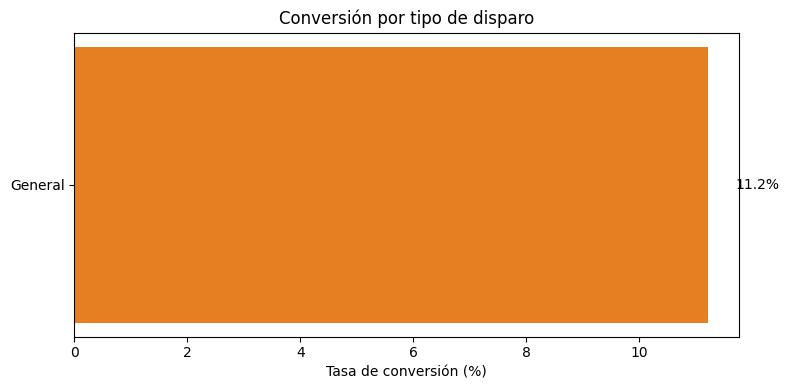

In [5]:
types = ['is_penalty', 'is_big_chance', 'is_header', 'is_counter']
conv_type = {t: shots[shots[t]==1]['is_goal'].mean()*100 for t in types}
conv_type['General'] = shots['is_goal'].mean()*100
conv_type = pd.Series(conv_type).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8,4))
bars = ax.barh(conv_type.index, conv_type.values, color='#e67e22')
for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.1f}%", va='center')
ax.set_title('Conversión por tipo de disparo')
ax.set_xlabel('Tasa de conversión (%)')
plt.tight_layout(); plt.savefig('figures/conversion_by_type.png', dpi=150, bbox_inches='tight'); plt.show()

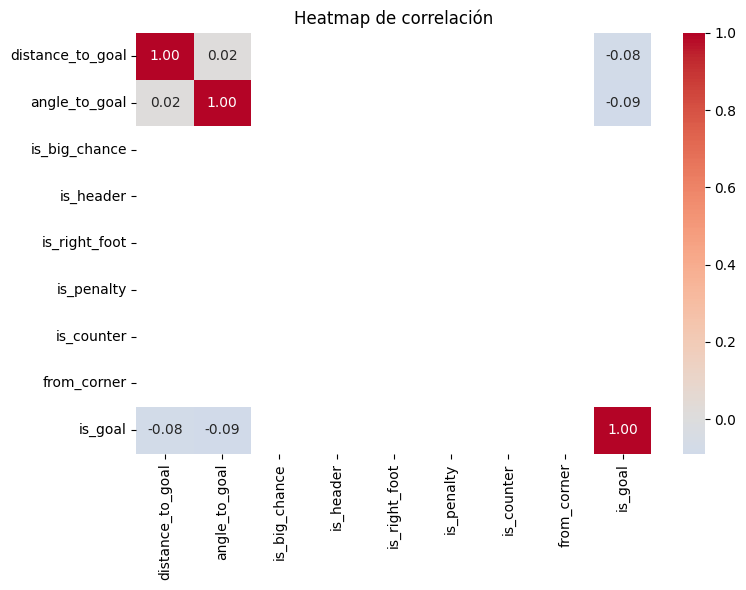

In [6]:
cols = ['distance_to_goal','angle_to_goal','is_big_chance','is_header',
        'is_right_foot','is_penalty','is_counter','from_corner','is_goal']
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(shots[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Heatmap de correlación')
plt.tight_layout(); plt.savefig('figures/correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()

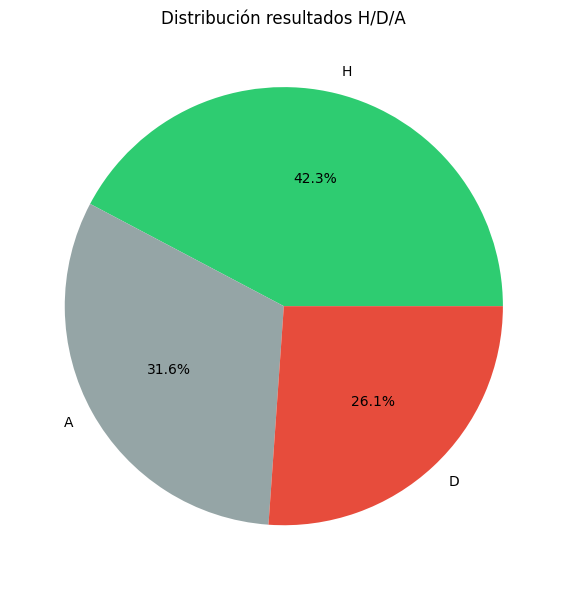

In [7]:
results = matches['result'].value_counts(normalize=True) * 100
fig, ax = plt.subplots(figsize=(6,6))
ax.pie(results.values, labels=results.index, autopct='%1.1f%%', colors=['#2ecc71', '#95a5a6', '#e74c3c'])
ax.set_title('Distribución resultados H/D/A')
plt.tight_layout(); plt.savefig('figures/results_distribution.png', dpi=150, bbox_inches='tight'); plt.show()

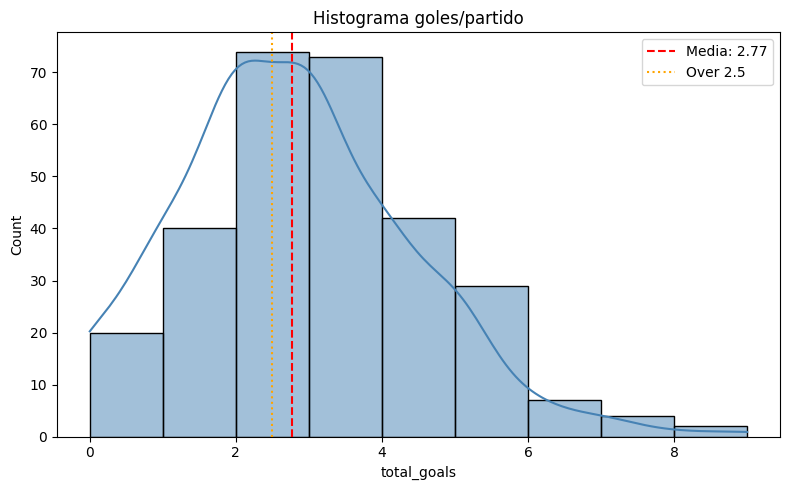

In [8]:
matches['total_goals'] = matches['home_goals'] + matches['away_goals']
fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(matches['total_goals'], kde=True, ax=ax, color='steelblue', binwidth=1)
mean_g = matches['total_goals'].mean()
ax.axvline(mean_g, color='red', linestyle='--', label=f"Media: {mean_g:.2f}")
ax.axvline(2.5, color='orange', linestyle=':', label='Over 2.5')
ax.set_title('Histograma goles/partido')
ax.legend()
plt.tight_layout(); plt.savefig('figures/goals_per_match.png', dpi=150, bbox_inches='tight'); plt.show()

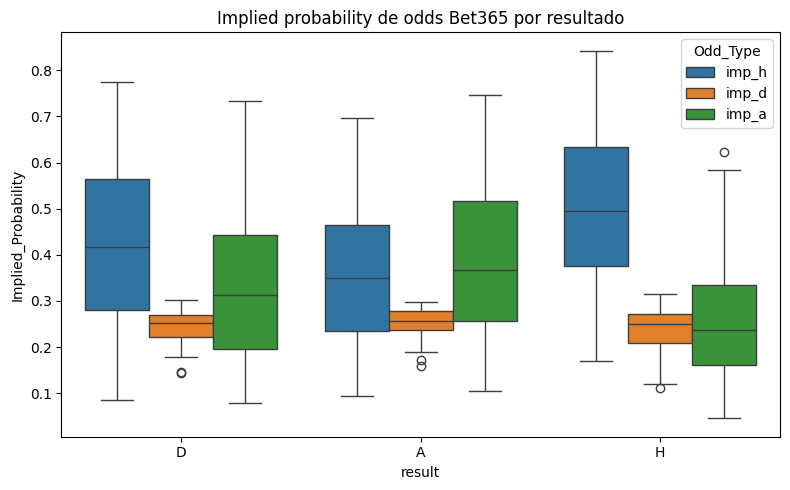

In [9]:
matches['imp_h'] = (1/matches['b365h']) / (1/matches['b365h']+1/matches['b365d']+1/matches['b365a'])
matches['imp_d'] = (1/matches['b365d']) / (1/matches['b365h']+1/matches['b365d']+1/matches['b365a'])
matches['imp_a'] = (1/matches['b365a']) / (1/matches['b365h']+1/matches['b365d']+1/matches['b365a'])
melted = matches.melt(id_vars=['result'], value_vars=['imp_h','imp_d','imp_a'], var_name='Odd_Type', value_name='Implied_Probability')
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=melted, x='result', y='Implied_Probability', hue='Odd_Type', ax=ax)
ax.set_title('Implied probability de odds Bet365 por resultado')
plt.tight_layout(); plt.savefig('figures/implied_probability.png', dpi=150, bbox_inches='tight'); plt.show()

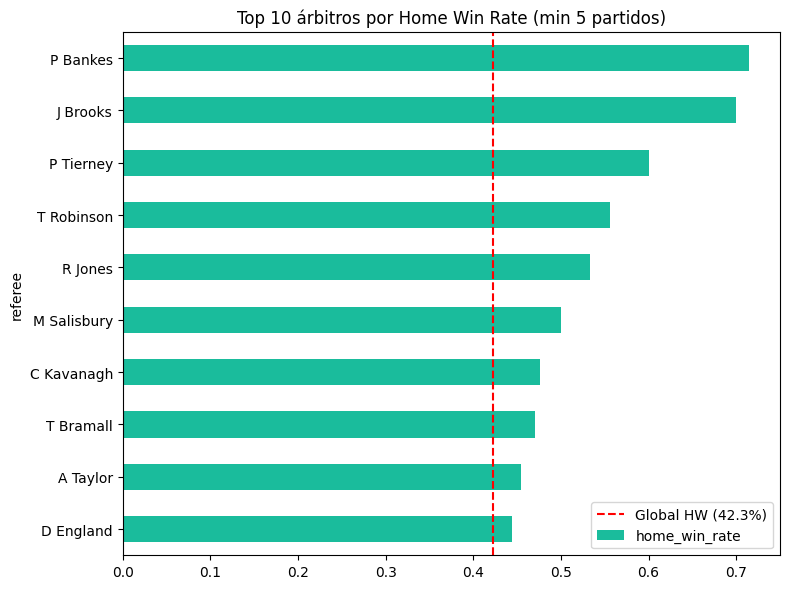

In [10]:
referee_stats = matches.groupby('referee').agg(
    partidos=('result','count'),
    home_win_rate=('result', lambda x: (x=='H').mean()),
    tarjetas=('home_yellow_cards','mean')  
).query('partidos >= 5').sort_values('home_win_rate', ascending=False).head(10)
global_hw = (matches['result']=='H').mean()
referee_stats['diferencia'] = referee_stats['home_win_rate'] - global_hw

fig, ax = plt.subplots(figsize=(8,6))
referee_stats['home_win_rate'].sort_values().plot(kind='barh', ax=ax, color='#1abc9c')
ax.axvline(global_hw, color='red', linestyle='--', label=f'Global HW ({global_hw:.1%})')
ax.set_title('Top 10 árbitros por Home Win Rate (min 5 partidos)')
ax.legend()
plt.tight_layout(); plt.savefig('figures/referee_bias.png', dpi=150, bbox_inches='tight'); plt.show()

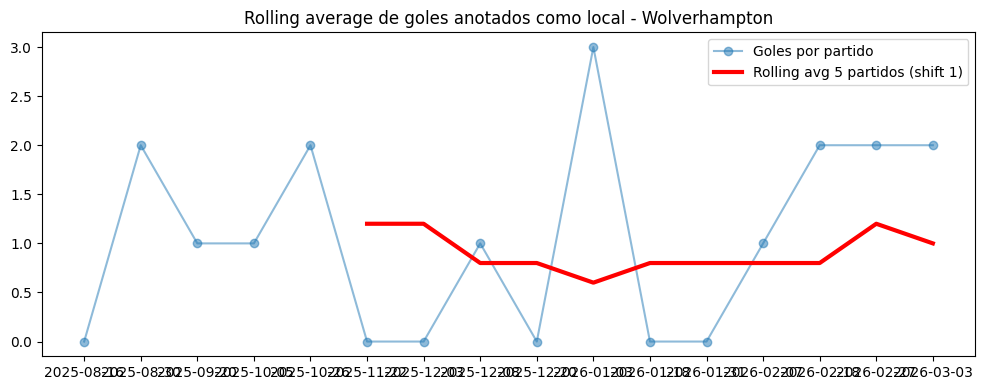

In [11]:
top_team = matches['home_team'].value_counts().index[0]
team_matches = matches[matches['home_team'] == top_team].sort_values('date').copy()
team_matches['rolling_goals'] = team_matches['home_goals'].shift(1).rolling(5).mean()
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(team_matches['date'], team_matches['home_goals'], label='Goles por partido', marker='o', alpha=0.5)
ax.plot(team_matches['date'], team_matches['rolling_goals'], label='Rolling avg 5 partidos (shift 1)', linewidth=3, color='red')
ax.set_title(f'Rolling average de goles anotados como local - {top_team}')
ax.legend()
plt.tight_layout(); plt.savefig('figures/rolling_goals.png', dpi=150, bbox_inches='tight'); plt.show()

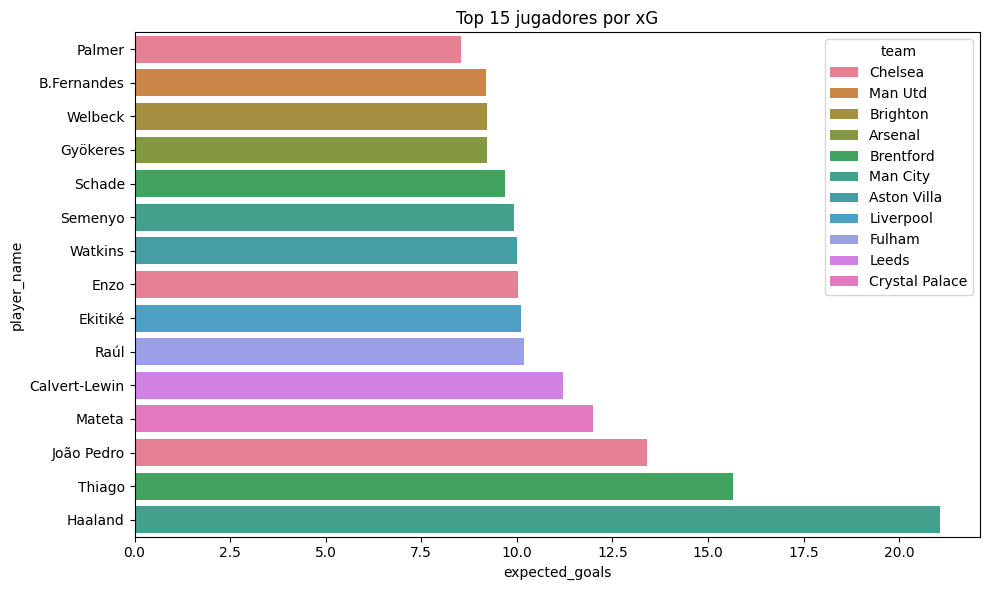

In [12]:
top_players = players.nlargest(15, 'expected_goals').sort_values('expected_goals', ascending=True)
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(data=top_players, x='expected_goals', y='player_name', hue='team', dodge=False, ax=ax)
ax.set_title('Top 15 jugadores por xG')
plt.tight_layout(); plt.savefig('figures/top_players_xg.png', dpi=150, bbox_inches='tight'); plt.show()

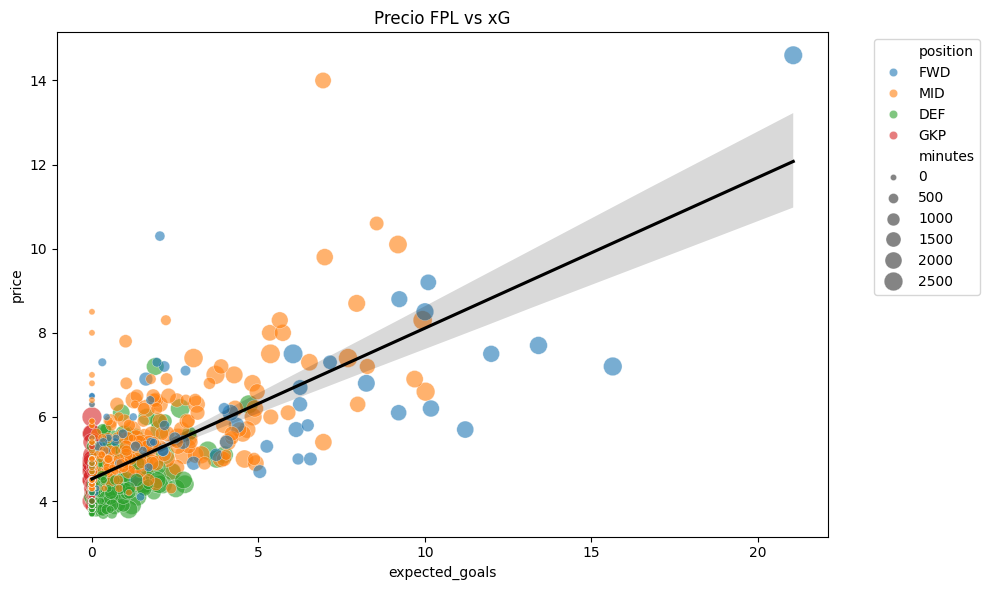

In [13]:
fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(data=players, x='expected_goals', y='price', hue='position', size='minutes', sizes=(20,200), alpha=0.6, ax=ax)
sns.regplot(data=players, x='expected_goals', y='price', scatter=False, color='black', ax=ax)
ax.set_title('Precio FPL vs xG')
ax.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout(); plt.savefig('figures/price_vs_xg.png', dpi=150, bbox_inches='tight'); plt.show()

## Insights accionables para feature engineering
1. Los tiros desde <10m tienen mucha mayor conversión vs en >20m → distance_to_goal es el predictor más importante.
2. BigChance tiene la mayor conversión → is_big_chance es la feature booleana con mayor poder predictivo.
3. Las odds de Bet365 predicen correctamente el resultado en ~50% de los casos → las odds son features informativas pero con límite.
4. El árbitro con mayor sesgo tiene alto home win rate vs la media global → referee como feature categórica puede aportar.
5. Los equipos con rolling_goals_scored alto en últimos 5 partidos tienen más probabilidad de ganar → rolling features justificadas.